In [1]:
from config_features import FEATURES, LABEL
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Trainings- und Testdaten laden
train_df = pd.read_parquet('4_train_block.parquet')
test_df = pd.read_parquet('4_test_block.parquet')

In [2]:
print(FEATURES)

['node-stores', 'bus_access', 'skb_kfree_skb', 'cpu_cycles', 'l2d_cache_wb_victim', 'syscalls_sys_enter_fcntl', 'sched_sched_stat_runtime', 'st_spec', 'syscalls_sys_enter_kill', 'fib_fib_table_lookup', 'sock_inet_sock_set_state', 'l2d_cache_wb', 'unaligned_st_spec', 'mem_access_rd', 'l2d_cache_refill_wr', 'mmc_mmc_request_start', 'br_mis_pred']


In [3]:
# Label umwandeln: 'attack' → 1, 'benign' → 0
train_df[LABEL] = train_df[LABEL].map({'attack': 1, 'benign': 0})
test_df[LABEL] = test_df[LABEL].map({'attack': 1, 'benign': 0})

# Features und Label auswählen
X_train = train_df[FEATURES]
y_train = train_df[LABEL]
X_test = test_df[FEATURES]
y_test = test_df[LABEL]

# Features skalieren (Scaler auf Trainingsdaten fitten, auf beide anwenden)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
test_df.head()

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T19:53:10,847.0,540525.0,115706.0,15452.0,656131.0,96680.0,15185.0,651088.0,14893.0,...,-4.0,-4.0,-6.0,0.0,0.0,0.0,-3.0,-6.0,benign,0
1,2025-07-22T19:53:20,808.0,527069.0,112884.0,14933.0,639855.0,94312.0,14941.0,640294.0,14456.0,...,5.0,5.0,6.0,0.0,0.0,0.0,4.0,6.0,benign,0
2,2025-07-22T19:53:30,844.0,537613.0,115032.0,15021.0,652547.0,96070.0,14841.0,642126.0,15904.0,...,1.0,1.0,-1.0,0.0,0.0,0.0,1.0,-1.0,benign,0
3,2025-07-22T19:53:40,879.0,530950.0,113144.0,14686.0,643996.0,94525.0,14882.0,640138.0,15161.0,...,-2.0,-2.0,-2.0,0.0,0.0,0.0,-1.0,-2.0,benign,0
4,2025-07-22T19:53:50,872.0,533494.0,113819.0,14967.0,647215.0,95060.0,14997.0,650649.0,14580.0,...,-6.0,-6.0,-2.0,0.0,0.0,0.0,-5.0,-2.0,benign,0


In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def create_sequences(X, y, window_size=5):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        # Nur wenn alle Labels im Fenster gleich sind
        if np.all(label_window == label_window[0]):
            X_seq.append(X[i:i+window_size])
            y_seq.append(label_window[0])
    return np.array(X_seq), np.array(y_seq)

# Anwendung auf deine Daten (jetzt mit window_size=5)
X_sequences, y_sequences = create_sequences(X_train_scaled, y_train.values, window_size=5)


In [6]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, window_size=5)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, window_size=2)

print(X_train_seq.shape)  # (Anzahl Fenster, 10, Anzahl Features)
print(y_train_seq.shape)  # (Anzahl Fenster,)


(4681, 5, 17)
(4681,)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create a stacked LSTM model
def create_lstm_model(num_features):
    model = Sequential([
        # First LSTM layer (returns full sequences for stacking)
        LSTM(50, input_shape=(5, num_features), return_sequences=True),
        Dropout(0.2),  # Dropout to prevent overfitting
        # Second LSTM layer (only returns final output)
        LSTM(15),
        Dropout(0.2),  # Additional regularization
        # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model with binary crossentropy loss and accuracy metric
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Create model with number of selected input features
model = create_lstm_model(len(FEATURES))

# Print model summary
model.summary()

# Print number of selected features
print(len(FEATURES))

2025-07-31 06:09:40.404707: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-31 06:09:40.405373: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 06:09:40.408573: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 06:09:40.415470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753934980.427686 3769568 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753934980.43

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 50)          │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15)             │         3,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,576 (68.66 KB)

 Trainable params: 17,576 (68.66 KB)

 Non-trainable params: 0 (0.00 B)

17


In [8]:
history = model.fit(
    X_sequences, y_sequences,
    epochs=25,         # Anzahl der Durchläufe, du kannst anpassen
    batch_size=64,     # Größe der Trainingsbatches (vorerst Standard)
#    validation_split=0.2  # 20% der Daten werden für Validierung verwendet
)


Epoch 1/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8881 - loss: 0.5278
Epoch 2/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9728 - loss: 0.1296
Epoch 3/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9706 - loss: 0.1305
Epoch 4/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9804 - loss: 0.0923
Epoch 5/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9789 - loss: 0.0965
Epoch 6/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9815 - loss: 0.0859
Epoch 7/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9807 - loss: 0.0842
Epoch 8/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9822 - loss: 0.0772
Epoch 9/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9771 - loss: 0.0919
Epoch 10/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9813 - loss: 0.0764
Epoch 11/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9790 - loss: 0.0797
Epoch 12/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9804 - lo

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[1575  149]
 [ 112  189]]


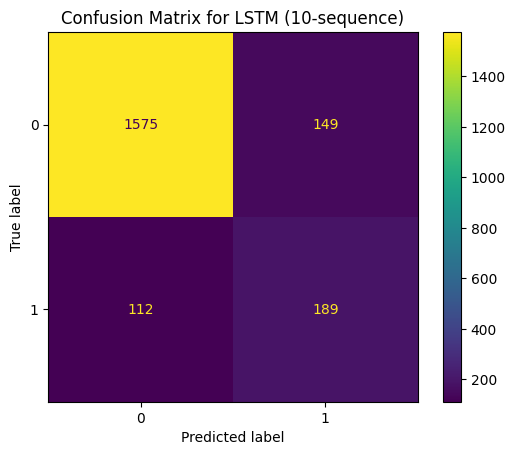

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# 1. Make predictions for the test data – NOTE: use _seq!
y_pred_seq = (model.predict(X_test_seq) > 0.4).astype(int).flatten()

# 2. Compute the confusion matrix – the lengths match now!
cm = confusion_matrix(y_test_seq, y_pred_seq)

# 3. Print the confusion matrix as numbers
print(cm)

# 4. Display the confusion matrix as a graphic
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for LSTM (10-sequence)')

output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = f"confusion_matrix.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [10]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Vorhersage für Sequenzdaten
y_pred_prob = model.predict(X_test_seq)

# 2. Wahrscheinlichkeiten zu Klassenlabels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Genauigkeit und Klassifikationsbericht (jetzt gleiche Länge!)
accuracy = accuracy_score(y_test_seq, y_pred)
report = classification_report(y_test_seq, y_pred)

# 4. Ausgabe
print(f"Genauigkeit: {accuracy:.4f}")
print(report)


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step
Genauigkeit: 0.8909
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1724
           1       0.67      0.52      0.59       301

    accuracy                           0.89      2025
   macro avg       0.79      0.74      0.76      2025
weighted avg       0.88      0.89      0.89      2025



In [13]:
import pandas as pd
import numpy as np

window_size = 2  # muss mit create_sequences(...) übereinstimmen!
attack_array = test_df["attack"].values
label_array = y_test.values  # oder y_test direkt

# Filtere die Attacktypen passend zu den Sequenzen
attack_seq = np.array([
    attack_array[i]
    for i in range(len(attack_array) - window_size + 1)
    if np.all(label_array[i:i+window_size] == label_array[i])
])

# Sanity-Check:
assert len(attack_seq) == len(y_test_seq) == len(y_pred_seq), "Längen stimmen nicht überein!"

# Erstelle das DataFrame
df = pd.DataFrame({
    "y_true": y_test_seq,
    "y_pred": y_pred_seq,
    "attack": attack_seq
})

# Filter: misclassified attacks (true=1, pred=0)
misclassified = df[(df["y_true"] == 1) & (df["y_pred"] == 0)]

# Count misclassified and total attacks
misclassified_counts = misclassified["attack"].value_counts()
total_counts = df[df["y_true"] == 1]["attack"].value_counts()

# Combine into single table
summary = pd.DataFrame({
    "misclassified": misclassified_counts,
    "total": total_counts
}).fillna(0).astype(int)

print(summary.sort_values("misclassified", ascending=False))

                  misclassified  total
attack                                
osfingerprinting             41     59
aggressivescan               36     59
slowloris                    29     45
synonymousflood               4     76
portscan                      2     59
tcpflood                      0      3


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step


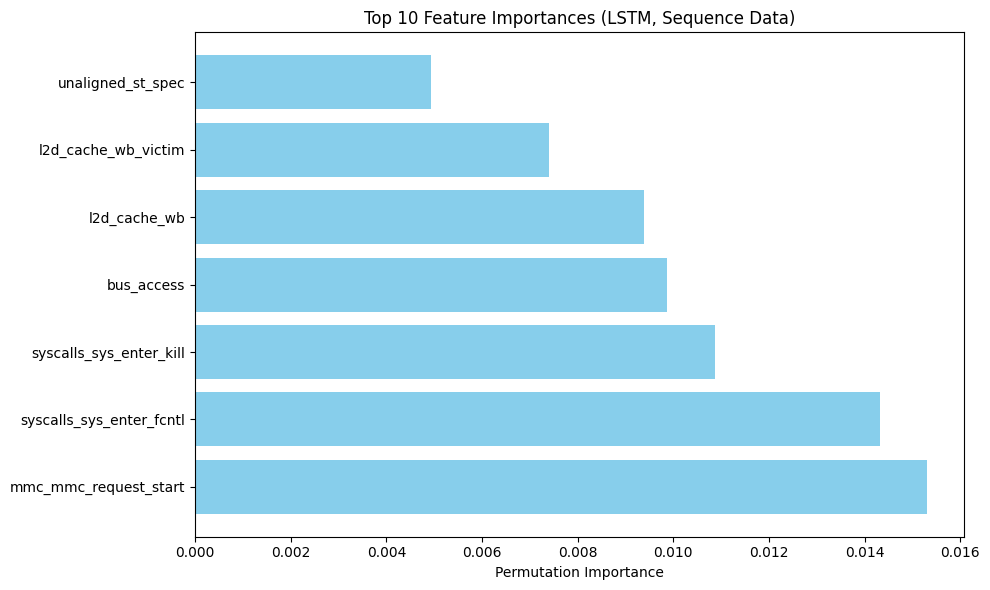

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Assumption: model, X_test_seq, y_test_seq, FEATURES are already defined

# 1. Baseline accuracy for the sequenced test set
y_pred_seq = model.predict(X_test_seq)
original_acc = accuracy_score(y_test_seq, (y_pred_seq > 0.5).astype(int))

feature_importances = []
for i in range(X_test_seq.shape[2]):
    X_test_perm = X_test_seq.copy()
    # Shuffle the i-th feature across all windows and time steps
    np.random.shuffle(X_test_perm[:, :, i])
    y_pred_perm = model.predict(X_test_perm)
    perm_acc = accuracy_score(y_test_seq, (y_pred_perm > 0.5).astype(int))
    feature_importances.append(original_acc - perm_acc)

# 2. Find top 10 features
indices_top10 = np.argsort(feature_importances)[10:][::-1]
top10_features = [FEATURES[i] for i in indices_top10]
top10_importances = [feature_importances[i] for i in indices_top10]

# 3. Draw bar chart for top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top10_features, top10_importances, color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Top 10 Feature Importances (LSTM, Sequence Data)')
plt.tight_layout()
output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = f"feature_importances_lstm.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [15]:
from tensorflow.keras.models import load_model
import joblib

model.save('lstm_model_20events.keras')



In [16]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']